<a href="https://colab.research.google.com/github/adiipawarrrr/ClimateRiskAssessment/blob/main/Climate_Risk_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 📦 Step 1: Install required packages
!pip install folium geopy requests tensorflow sklearn matplotlib
!pip install -q transformers


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
# 🔐 Step 2: API Keys and Setup
import os

# Replace with your actual API keys
OPENCAGE_API_KEY = "c8d01cd61ff84ca5ac8cb56bf550e2b6"
WEATHER_API_KEY = "339cbb5eb260468a92264549252004"
OPENWEATHER_API_KEY = "20dfe5cfb0322eb64995c83dc7e5bfb6"
USGS_BASE_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"


In [ ]:
# 📍 Step 3: Get and validate location from user

from geopy.geocoders import OpenCage
from geopy.exc import GeocoderTimedOut

def get_coordinates(location):
    geolocator = OpenCage(OPENCAGE_API_KEY)
    try:
        location_data = geolocator.geocode(location)
        if location_data:
            return location_data.latitude, location_data.longitude
        else:
            return None
    except GeocoderTimedOut:
        return None

user_location = input("📍 Enter a location for climate risk assessment: ")
coordinates = get_coordinates(user_location)

if not coordinates:
    print("❌ Invalid location. Please try again.")
else:
    lat, lon = coordinates
    print(f"✅ Coordinates for {user_location}: {lat}, {lon}")


📍 Enter a location for climate risk assessment: Delhi
✅ Coordinates for Delhi: 28.6273928, 77.1716954


In [ ]:
# 📈 Step 4: Fetch Historical Weather Data
import requests
import pandas as pd
from datetime import datetime, timedelta

def fetch_past_weather(lat, lon, days=30):
    base_url = "http://api.weatherapi.com/v1/history.json"
    end_date = datetime.today()
    records = []

    for i in range(days):
        date = (end_date - timedelta(days=i)).strftime('%Y-%m-%d')
        params = {
            "key": WEATHER_API_KEY,
            "q": f"{lat},{lon}",
            "dt": date
        }
        response = requests.get(base_url, params=params)
        if response.status_code == 200:
            data = response.json()
            day_data = data['forecast']['forecastday'][0]['day']
            records.append({
                "date": date,
                "avg_temp_c": day_data['avgtemp_c'],
                "precip_mm": day_data['totalprecip_mm']
            })

    return pd.DataFrame(records)

weather_df = fetch_past_weather(lat, lon)
weather_df['date'] = pd.to_datetime(weather_df['date'])
print("📊 Sample Historical Weather Data:")
print(weather_df.head())

📊 Sample Historical Weather Data:
        date  avg_temp_c  precip_mm
0 2025-05-02        35.3       0.89
1 2025-05-01        35.8       0.00
2 2025-04-30        36.5       0.00
3 2025-04-29        37.1       0.00
4 2025-04-28        34.5       0.00


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbsw_ld6q/f6hhex6r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbsw_ld6q/o65zrwwm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63540', 'data', 'file=/tmp/tmpbsw_ld6q/f6hhex6r.json', 'init=/tmp/tmpbsw_ld6q/o65zrwwm.json', 'output', 'file=/tmp/tmpbsw_ld6q/prophet_model_5cz55pb/prophet_model-20250502080702.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:07:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:07:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:

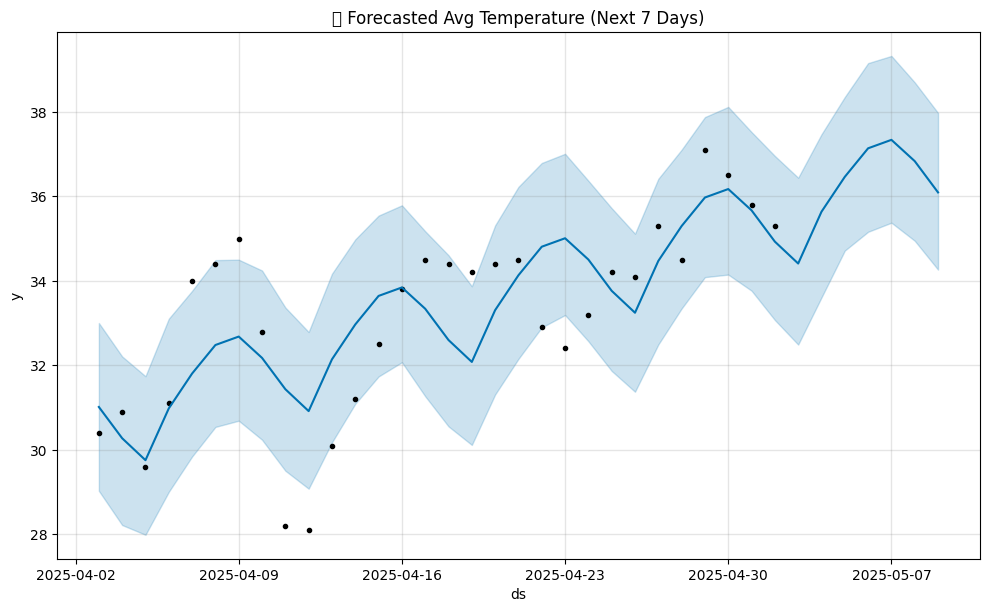

⚠️ Predicted Heatwave Risk:
            ds       yhat  heatwave_risk
30 2025-05-03  34.408580          False
31 2025-05-04  35.633769          False
32 2025-05-05  36.458942          False
33 2025-05-06  37.134007          False
34 2025-05-07  37.334052          False
35 2025-05-08  36.830255          False
36 2025-05-09  36.090392          False


In [ ]:
# ⏳ Step 5: Forecasting using Facebook Prophet
from prophet import Prophet
import matplotlib.pyplot as plt

# Forecast temperature
temp_df = weather_df[['date', 'avg_temp_c']].rename(columns={"date": "ds", "avg_temp_c": "y"})
model_temp = Prophet()
model_temp.fit(temp_df)
future_temp = model_temp.make_future_dataframe(periods=7)
forecast_temp = model_temp.predict(future_temp)

# Plot
model_temp.plot(forecast_temp)
plt.title("🌡️ Forecasted Avg Temperature (Next 7 Days)")
plt.show()

# Flag heatwave risk if temperature > 40°C
forecast_temp['heatwave_risk'] = forecast_temp['yhat'] > 40
print("⚠️ Predicted Heatwave Risk:\n", forecast_temp[['ds', 'yhat', 'heatwave_risk']].tail(7))

In [ ]:
# 🌦️ Step 4: Get current weather data

import requests

def get_weather_data(lat, lon):
    url = f"http://api.weatherapi.com/v1/current.json?key={WEATHER_API_KEY}&q={lat},{lon}"
    response = requests.get(url)
    return response.json()

weather_data = get_weather_data(lat, lon)
print("🌡️ Weather Info:")
print(weather_data['current'])


🌡️ Weather Info:
{'last_updated_epoch': 1746172800, 'last_updated': '2025-05-02 13:30', 'temp_c': 25.4, 'temp_f': 77.7, 'is_day': 1, 'condition': {'text': 'Mist', 'icon': '//cdn.weatherapi.com/weather/64x64/day/143.png', 'code': 1030}, 'wind_mph': 4.0, 'wind_kph': 6.5, 'wind_degree': 91, 'wind_dir': 'E', 'pressure_mb': 1010.0, 'pressure_in': 29.83, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 69, 'cloud': 75, 'feelslike_c': 24.1, 'feelslike_f': 75.3, 'windchill_c': 38.8, 'windchill_f': 101.9, 'heatindex_c': 38.2, 'heatindex_f': 100.7, 'dewpoint_c': 9.4, 'dewpoint_f': 48.9, 'vis_km': 4.5, 'vis_miles': 2.0, 'uv': 7.0, 'gust_mph': 4.6, 'gust_kph': 7.5}


In [ ]:
# 🌍 Step 5: Get USGS earthquake data from the past 5 years

import datetime

def get_usgs_earthquake_data(lat, lon, radius_km=100):
    end_time = datetime.date.today()
    start_time = end_time - datetime.timedelta(days=365*5)
    url = (
        f"{USGS_BASE_URL}?format=geojson&starttime={start_time}&endtime={end_time}"
        f"&latitude={lat}&longitude={lon}&maxradiuskm={radius_km}"
    )
    response = requests.get(url)
    return response.json()

earthquake_data = get_usgs_earthquake_data(lat, lon)
print(f"🌋 Earthquakes in the past 5 years within 100km: {len(earthquake_data['features'])}")


🌋 Earthquakes in the past 5 years within 100km: 8


<ipython-input-8-41f374ccf20d>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start="1970-01-01", end="2020-12-01", freq='M')


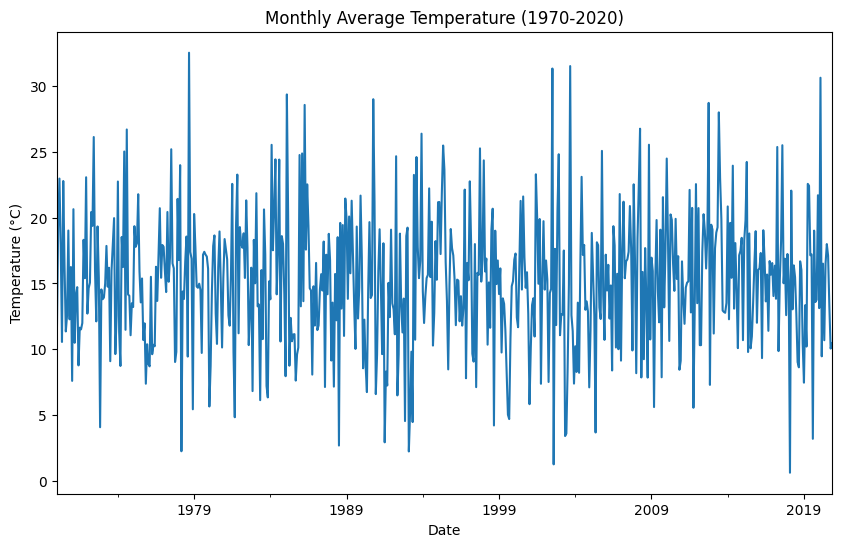

In [ ]:
# 📈 Step 6: Prepare data for LSTM-based climate forecasting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Example: Generating dummy temperature data for 50 years (monthly data)
months = pd.date_range(start="1970-01-01", end="2020-12-01", freq='M')
temperature_data = np.random.normal(loc=15, scale=5, size=len(months))  # Fake data, replace with real

df = pd.DataFrame({'Date': months, 'Temperature': temperature_data})
df.set_index('Date', inplace=True)

# Visualize the data
df['Temperature'].plot(figsize=(10, 6))
plt.title("Monthly Average Temperature (1970-2020)")
plt.ylabel("Temperature (°C)")
plt.show()

# Normalize the temperature data to scale between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Temperature']])

# Create the dataset for LSTM (use past 12 months to predict next month)
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])  # Last 12 months
        y.append(data[i, 0])  # Temperature next month
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

# Reshape input data for LSTM [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:
# 🧠 Step 7: Build and train the LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Build LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))  # Predicting one value (next month's temperature)

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.1174 - val_loss: 0.0359
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0332 - val_loss: 0.0269
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0322 - val_loss: 0.0246
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0281 - val_loss: 0.0246
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0281 - val_loss: 0.0246
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0298 - val_loss: 0.0245
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0255 - val_loss: 0.0255
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0323 - val_loss: 0.0249
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0277 - val_loss: 0.0247
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0272 - val_loss: 0.0248
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0277 - val_loss: 0.0246
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0299 - val_l

In [ ]:
from transformers import pipeline

from transformers import pipeline

# Initialize the Hugging Face model pipeline for text generation (adjust model as needed)
risk_assessor_model = pipeline("text-generation", model="gpt2")

def risk_assessor(prompt, max_length=200, do_sample=True, temperature=0.7):
    """
    This function uses a language model to generate a climate risk assessment based on the input prompt.
    """
    print(f"Risk Assessor called with prompt: {prompt}")
    try:
        response = risk_assessor_model(prompt, max_length=max_length, do_sample=do_sample, temperature=temperature)
        return response
    except Exception as e:
        print(f"Error generating response: {str(e)}")
        return None

# 🗓️ Step 8: Predict future temperatures and generate a climate risk scenario

# Example of using predicted temperatures for climate risk projection
future_temperatures = [30, 31, 32]  # Example future temperatures (from your prediction model)

# Projection context for climate risk
projection_context = f"""
By 2040, the average temperature in {user_location} is projected to rise from {weather_data['current']['temp_c']:.2f}°C to {future_temperatures[-1]:.2f}°C.
"""

# Call the risk assessor (AI model) to generate the risk scenario
projection_response = risk_assessor(
    f"{projection_context}\nPossible climate-related impacts include:",
    max_length=250,
    do_sample=True,
    temperature=0.85
)

if projection_response:
    print("🌍 Future Climate Risk Scenario:\n")
    print(projection_response[0]['generated_text'])



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Risk Assessor called with prompt: 
By 2040, the average temperature in Delhi is projected to rise from 25.40°C to 32.00°C.

Possible climate-related impacts include:
🌍 Future Climate Risk Scenario:


By 2040, the average temperature in Delhi is projected to rise from 25.40°C to 32.00°C.

Possible climate-related impacts include:


In [ ]:
# 🗺️ Step 9: Create Interactive Map with Risk Levels

import folium

# 🟢🟡🔴 Define risk level logic
def classify_risk(temp, quakes):
    if temp < 25 and quakes < 5:
        return "Low", "green"
    elif temp < 30 and quakes < 15:
        return "Medium", "orange"
    else:
        return "High", "red"

risk_level, color = classify_risk(weather_data['current']['temp_c'], len(earthquake_data['features']))

# 🌍 Create folium map
m = folium.Map(location=[lat, lon], zoom_start=6)

# Add marker with tooltip and popup
tooltip = f"{user_location} ({risk_level} Risk)"
popup_text = f"<b>Location:</b> {user_location}<br><b>Temperature:</b> {weather_data['current']['temp_c']}°C<br><b>Earthquakes:</b> {len(earthquake_data['features'])}<br><b>Risk Level:</b> {risk_level}"

folium.CircleMarker(
    location=[lat, lon],
    radius=10,
    color=color,
    fill=True,
    fill_color=color,
    fill_opacity=0.7,
    tooltip=tooltip,
    popup=popup_text,
).add_to(m)

m


In [ ]:
# 🌫 Step 10: Real-Time Air Quality Index (AQI)

def get_air_quality(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OPENWEATHER_API_KEY}"
    data = requests.get(url).json()
    aqi = data['list'][0]['main']['aqi']
    aqi_map = {
        1: "Good",
        2: "Fair",
        3: "Moderate",
        4: "Poor",
        5: "Very Poor"
    }
    return aqi, aqi_map[aqi]

aqi_val, aqi_desc = get_air_quality(lat, lon)
print(f"🫁 Air Quality in {user_location}: {aqi_desc} (AQI {aqi_val})")


🫁 Air Quality in Delhi: Poor (AQI 4)


In [ ]:
# 🌊 Step 11: Elevation-Based Flood Risk

def get_elevation(lat, lon):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    response = requests.get(url).json()
    elevation = response['results'][0]['elevation']
    return elevation

elevation = get_elevation(lat, lon)
flood_risk = "High" if elevation < 20 else "Medium" if elevation < 100 else "Low"
print(f"🌊 Elevation: {elevation}m — Flood Risk: {flood_risk}")


🌊 Elevation: 255.0m — Flood Risk: Low


In [ ]:
# 💬 Chatbot for Climate Q&A

import ipywidgets as widgets
from IPython.display import display, clear_output

chat_history = widgets.Output()

user_input = widgets.Text(
    placeholder='Ask me anything about climate risks here...',
    description='You:',
    layout=widgets.Layout(width='100%')
)

send_button = widgets.Button(
    description='Send',
    button_style='info',
    tooltip='Send your question',
    icon='paper-plane'
)

def chatbot_response(change=None):
    question = user_input.value.strip()
    if not question:
        return

    with chat_history:
        print(f"👤 You: {question}")
        try:
            reply = risk_assessor(
                f"{question}\n(Location: {user_location}, Temp: {weather_data['current']['temp_c']}°C, Elev: {elevation}m, Quakes: {len(earthquake_data['features'])})",
                max_length=200,
                do_sample=True,
                temperature=0.8
            )[0]['generated_text']
            print(f"🤖 AI: {reply}\n")
        except Exception as e:
            print("❌ Sorry, there was an error processing your request.")
            print(str(e))

    user_input.value = ''

send_button.on_click(chatbot_response)
user_input.on_submit(chatbot_response)

chat_ui = widgets.VBox([
    chat_history,
    widgets.HBox([user_input, send_button])
])


In [ ]:
# 💬 Chatbot for Climate Q&A

import ipywidgets as widgets
from IPython.display import display, clear_output

chat_history = widgets.Output()

user_input = widgets.Text(
    placeholder='Ask me anything about climate risks here...',
    description='You:',
    layout=widgets.Layout(width='100%')
)

send_button = widgets.Button(
    description='Send',
    button_style='info',
    tooltip='Send your question',
    icon='paper-plane'
)

def chatbot_response(change=None):
    question = user_input.value.strip()
    if not question:
        return

    with chat_history:
        print(f"👤 You: {question}")
        try:
            reply = risk_assessor(
                f"{question}\n(Location: {user_location}, Temp: {weather_data['current']['temp_c']}°C, Elev: {elevation}m, Quakes: {len(earthquake_data['features'])})",
                max_length=200,
                do_sample=True,
                temperature=0.8
            )[0]['generated_text']
            print(f"🤖 AI: {reply}\n")
        except Exception as e:
            print("❌ Sorry, there was an error processing your request.")
            print(str(e))

    user_input.value = ''

send_button.on_click(chatbot_response)
user_input.on_submit(chatbot_response)

chat_ui = widgets.VBox([
    chat_history,
    widgets.HBox([user_input, send_button])
])


In [ ]:
# ✅ Function to build the final dashboard UI

def display_dashboard():
    # Rebuild all sections from latest data
    location_info = f"""
    **Location:** {user_location}
    **Latitude:** {lat}
    **Longitude:** {lon}
    """

    weather_info = f"""
    **Temperature:** {weather_data['current']['temp_c']} °C
    **Condition:** {weather_data['current']['condition']['text']}
    **Wind Speed:** {weather_data['current']['wind_kph']} km/h
    **Humidity:** {weather_data['current']['humidity']}%
    """

    aqi_info = f"""
    **AQI Level:** {aqi_val}
    **Description:** {aqi_desc}
    """

    earthquake_info = f"""
    **Earthquakes (last 5 years within 100km):** {len(earthquake_data['features'])}
    """

    flood_info = f"""
    **Elevation:** {elevation} m
    **Flood Risk Level:** {flood_risk}
    """

    forecast_info = f"""
    **Predicted 2040 Temperature:** {future_temperatures[-1]:.2f} °C
    **Temperature Increase:** {future_temperatures[-1] - weather_data['current']['temp_c']:.2f} °C
    """

    risk_info = f"""
    **Risk Level:** {risk_level.upper()}
    **Visual Code:** {color.capitalize()}
    """

    ai_projection = projection_response[0]['generated_text']

    # 👇 Chatbot (defined previously)
    chatbot_tab = widgets.VBox([
        chat_scroll,
        widgets.HBox([user_input, send_button])
    ])

    # Final tab structure
    tab_contents = [
        ("📍 Location", location_info),
        ("🌦️ Weather", weather_info),
        ("🫁 Air Quality", aqi_info),
        ("🌋 Earthquakes", earthquake_info),
        ("🌊 Flood Risk", flood_info),
        ("🌡️ Forecast", forecast_info),
        ("🧠 AI Analysis", ai_projection),
        ("⚠️ Risk Level", risk_info),
        ("💬 Chatbot", chatbot_tab)
    ]

    children = [
        widgets.HTML(f"<pre>{content}</pre>") if isinstance(content, str) else content
        for _, content in tab_contents
    ]

    tabs = widgets.Tab()
    tabs.children = children

    for i, (title, _) in enumerate(tab_contents):
        tabs.set_title(i, title)

    display(Markdown("## 🔍 Climate Risk Summary Dashboard"))
    display(tabs)


In [ ]:
# 💬 Chatbot UI Components (must be defined before calling display_dashboard)

import ipywidgets as widgets
from IPython.display import display, clear_output

chat_output = widgets.Output()
chat_scroll = widgets.Box([chat_output], layout=widgets.Layout(overflow='auto', max_height='300px'))

user_input = widgets.Text(
    placeholder='Ask something about this location...',
    layout=widgets.Layout(flex='1 1 auto', width='auto')
)

send_button = widgets.Button(
    icon='paper-plane',
    button_style='primary',
    tooltip='Send',
    layout=widgets.Layout(width='80px')
)

def on_chat_submit(change=None):
    question = user_input.value.strip()
    if not question:
        return

    with chat_output:
        print(f"👤 You: {question}")
        try:
            ai_response = risk_assessor(
                f"{question}\n(Location: {user_location}, Temp: {weather_data['current']['temp_c']}°C, Elev: {elevation}m, Quakes: {len(earthquake_data['features'])})",
                max_length=200,
                do_sample=True,
                temperature=0.8
            )[0]['generated_text']
            print(f"🤖 AI: {ai_response}\n")
        except Exception as e:
            print("❌ Error:", str(e))

    user_input.value = ''

send_button.on_click(on_chat_submit)
user_input.on_submit(on_chat_submit)


In [ ]:
from IPython.display import display, Markdown
import ipywidgets as widgets

# ✅ Final dashboard function with elegant formatting and layout
def display_dashboard():
    # Sections with nicely formatted Markdown
    location_info = f"""
### 📍 Location Info
- **City:** {user_location}
- **Latitude:** `{lat}`
- **Longitude:** `{lon}`
"""

    weather_info = f"""
### 🌦️ Current Weather
- **Temperature:** `{weather_data['current']['temp_c']} °C`
- **Condition:** `{weather_data['current']['condition']['text']}`
- **Wind Speed:** `{weather_data['current']['wind_kph']} km/h`
- **Humidity:** `{weather_data['current']['humidity']}%`
"""

    aqi_info = f"""
### 🫁 Air Quality Index
- **AQI Level:** `{aqi_val}`
- **Description:** `{aqi_desc}`
"""

    earthquake_info = f"""
### 🌋 Seismic Activity
- **Earthquakes (last 5 years within 100km):** `{len(earthquake_data['features'])}`
"""

    flood_info = f"""
### 🌊 Flood & Elevation
- **Elevation:** `{elevation} m`
- **Flood Risk Level:** `{flood_risk}`
"""

    forecast_info = f"""
### 🌡️ Future Temperature Forecast
- **Projected 2040 Temp:** `{future_temperatures[-1]:.2f} °C`
- **Increase since today:** `{future_temperatures[-1] - weather_data['current']['temp_c']:.2f} °C`
"""

    risk_info = f"""
### ⚠️ Climate Risk Summary
- **Risk Level:** `{risk_level.upper()}`
- **Color Code:** `{color.capitalize()}`
"""

    ai_analysis = f"""
### 🧠 AI Climate Risk Assessment
{projection_response[0]['generated_text']}
"""

    # ⬇️ Chatbot Box Tab
    chatbot_tab = widgets.VBox([
        widgets.HTML("<b>💬 Climate Chat Assistant</b>"),
        chat_scroll,
        widgets.HBox([user_input, send_button])
    ])

    # Tabs setup
    tab_contents = [
        ("📍 Location", location_info),
        ("🌦️ Weather", weather_info),
        ("🫁 Air Quality", aqi_info),
        ("🌋 Earthquakes", earthquake_info),
        ("🌊 Flood Risk", flood_info),
        ("🌡️ Forecast", forecast_info),
        ("🧠 AI Analysis", ai_analysis),
        ("⚠️ Risk Level", risk_info),
        ("💬 Chatbot", chatbot_tab)
    ]

    # Format the contents into HTML or widgets
    children = [
        widgets.HTML(value=f"<div style='padding:10px;'>{Markdown(content).data}</div>") if isinstance(content, str)
        else content
        for _, content in tab_contents
    ]

    # Create Tab UI
    tabs = widgets.Tab()
    tabs.children = children

    for i, (title, _) in enumerate(tab_contents):
        tabs.set_title(i, title)

    # Display Header and Tabs
    display(Markdown("## 🔍 Climate Risk Summary Dashboard"))
    display(tabs)


In [ ]:
# 🚀 Show the UI
display_dashboard()


## 🔍 Climate Risk Summary Dashboard